# 13 Mar 2026
- compare PSDs between inj trPL4par and inj trPL4par+CVpop

In [1]:
import numpy as np
from scipy import stats, interpolate
from matplotlib import pyplot as plt
import astropy.units as u
import astropy.constants as apyconst
import pandas as pd
import legwork as lw
#from sklearn.neighbors import KernelDensity
#from sklearn.model_selection import GridSearchCV
import copy
import corner
import pickle as pkl

%matplotlib inline
%config InlineBackend.figure_format='retina'

In [2]:
CV_plot = pkl.load(open('../storage/run_outputs/prod_runs/dur12p6e7_inj_trPL4parfixedgal_CVpop_rec_n_mwspecfixedgal/plot_data.pickle', 'rb'))
noCV_plot = pkl.load(open('../storage/run_outputs/prod_runs/dur12p6e7_inj_trPL4parfixedgal_rec_n_mwspecfixedgal/plot_data.pickle', 'rb'))



In [3]:
CV_plot

{'injspec_data': {'data_psd': {'psdfreqs': array([0.0001  , 0.000105, 0.00011 , ..., 0.00999 , 0.009995, 0.01    ],
         shape=(1981,)),
   'psd1': array([6.59731180e-38, 5.82968024e-38, 4.85947282e-38, ...,
          3.66565997e-41, 3.71497250e-41, 3.84394594e-41], shape=(1981,)),
   'psd2': array([6.49718208e-38, 5.84236466e-38, 4.96178061e-38, ...,
          3.65832523e-41, 3.60875684e-41, 3.60486102e-41], shape=(1981,)),
   'psd3': array([6.79654945e-38, 5.75146965e-38, 4.80960869e-38, ...,
          3.57949046e-41, 3.57580732e-41, 3.47155736e-41], shape=(1981,))},
  'noise_spectra': {'noise1': Array([6.9528484e-38, 5.7596147e-38, 4.8160560e-38, ..., 3.7106383e-41,
          3.7140014e-41, 3.7172244e-41], dtype=float32),
   'noise2': Array([6.9528484e-38, 5.7596147e-38, 4.8160560e-38, ..., 3.7106383e-41,
          3.7140014e-41, 3.7172244e-41], dtype=float32),
   'noise3': Array([6.9528484e-38, 5.7596147e-38, 4.8160560e-38, ..., 3.7106383e-41,
          3.7140014e-41, 3.7172244

In [20]:
def hztominperiod(x):
    x = np.array(x, float)
    period = x**-1 # seconds
    per = period / 60 # minutes
    return per

def minperiodtohz(x):
    x = np.array(x, float)
    per = x * 60 # seconds
    fr = per**-1 # hz
    return fr

/tmp/ipykernel_2459963/1818185784.py:10: RuntimeWarning: divide by zero encountered in reciprocal
  fr = per**-1 # hz


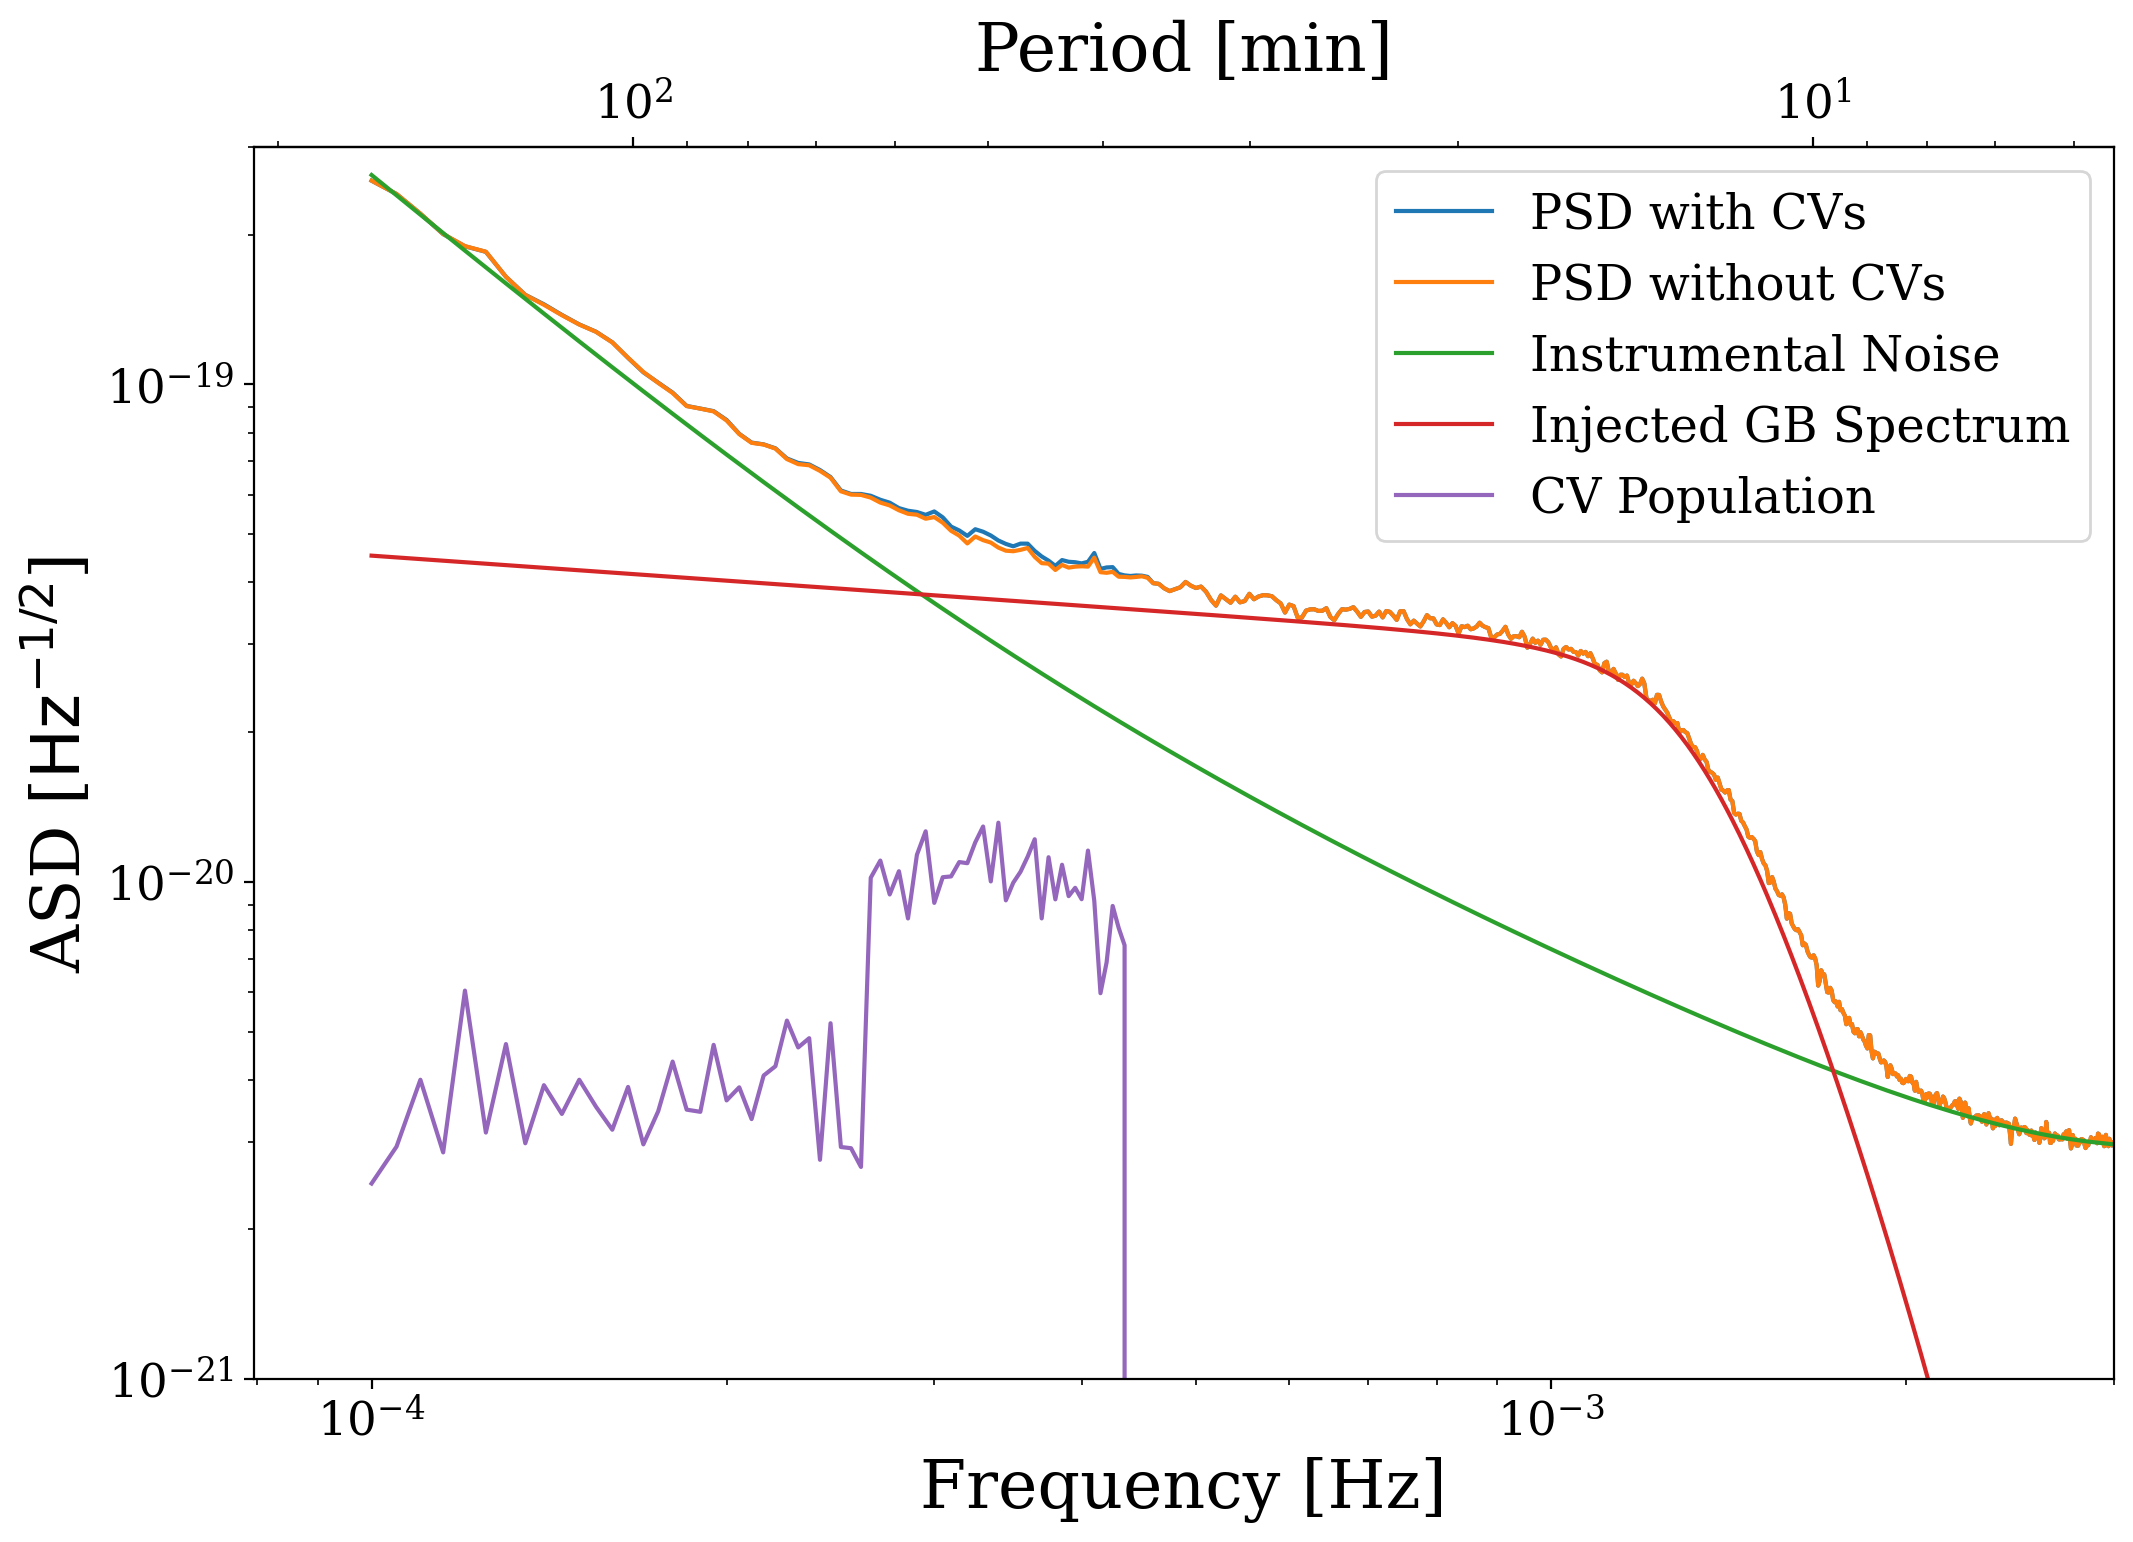

In [32]:
fig, ax = plt.subplots()

ax.plot(CV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(CV_plot['injspec_data']['data_psd']['psd1']), label='PSD with CVs')
ax.plot(noCV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(noCV_plot['injspec_data']['data_psd']['psd1']), label='PSD without CVs')
ax.plot(CV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(CV_plot['injspec_data']['noise_spectra']['noise1']), label='Instrumental Noise')
ax.plot(CV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(CV_plot['injspec_data']['truncatedpowerlaw4par_fixedgalaxy']['S1_gw']), label='Injected GB Spectrum')
ax.plot(CV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(CV_plot['injspec_data']['population']['S1_gw']), label='CV Population')

ax.loglog()
ax.set_xlim(right=3e-3)
ax.set_ylim(bottom=1e-21, top=3e-19)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel(r'ASD [$\rm{Hz}^{-1/2}$]')


secax = ax.secondary_xaxis('top', functions=(hztominperiod, minperiodtohz))
secax.set_xlabel('Period [min]')

plt.legend(fontsize='xx-large')
fig.savefig(f'/data/taylor_group/levi_schult/blip_CVs/notebooks/figures/aps2026/asd_comparison_i_trpl_CVpop.png', 
            dpi=400, bbox_inches='tight', format='png')

In [5]:
pops_CV_plot = pkl.load(open('../storage/run_outputs/prod_runs/dur12p6e7_inj_CVpop1_GBpop2_rec_n_mwspecfixedgal/plot_data.pickle', 'rb'))
pops_noCV_plot = pkl.load(open('../storage/run_outputs/prod_runs/dur12p6e7_inj_GBpop_rec_n_mwspecfixedgal/plot_data.pickle', 'rb'))

In [6]:
pops_CV_plot

{'injspec_data': {'data_psd': {'psdfreqs': array([0.0001  , 0.000105, 0.00011 , ..., 0.00999 , 0.009995, 0.01    ],
         shape=(1981,)),
   'psd1': array([6.39156373e-38, 5.61018421e-38, 4.79771721e-38, ...,
          3.66566515e-41, 3.71498165e-41, 3.84394648e-41], shape=(1981,)),
   'psd2': array([6.35014296e-38, 5.76849184e-38, 4.87535238e-38, ...,
          3.65833322e-41, 3.60876440e-41, 3.60485477e-41], shape=(1981,)),
   'psd3': array([6.64370447e-38, 5.58396284e-38, 4.77123865e-38, ...,
          3.57949222e-41, 3.57581833e-41, 3.47156405e-41], shape=(1981,))},
  'noise_spectra': {'noise1': Array([6.9528484e-38, 5.7596147e-38, 4.8160560e-38, ..., 3.7106383e-41,
          3.7140014e-41, 3.7172244e-41], dtype=float32),
   'noise2': Array([6.9528484e-38, 5.7596147e-38, 4.8160560e-38, ..., 3.7106383e-41,
          3.7140014e-41, 3.7172244e-41], dtype=float32),
   'noise3': Array([6.9528484e-38, 5.7596147e-38, 4.8160560e-38, ..., 3.7106383e-41,
          3.7140014e-41, 3.7172244

/tmp/ipykernel_2459963/1818185784.py:10: RuntimeWarning: divide by zero encountered in reciprocal
  fr = per**-1 # hz


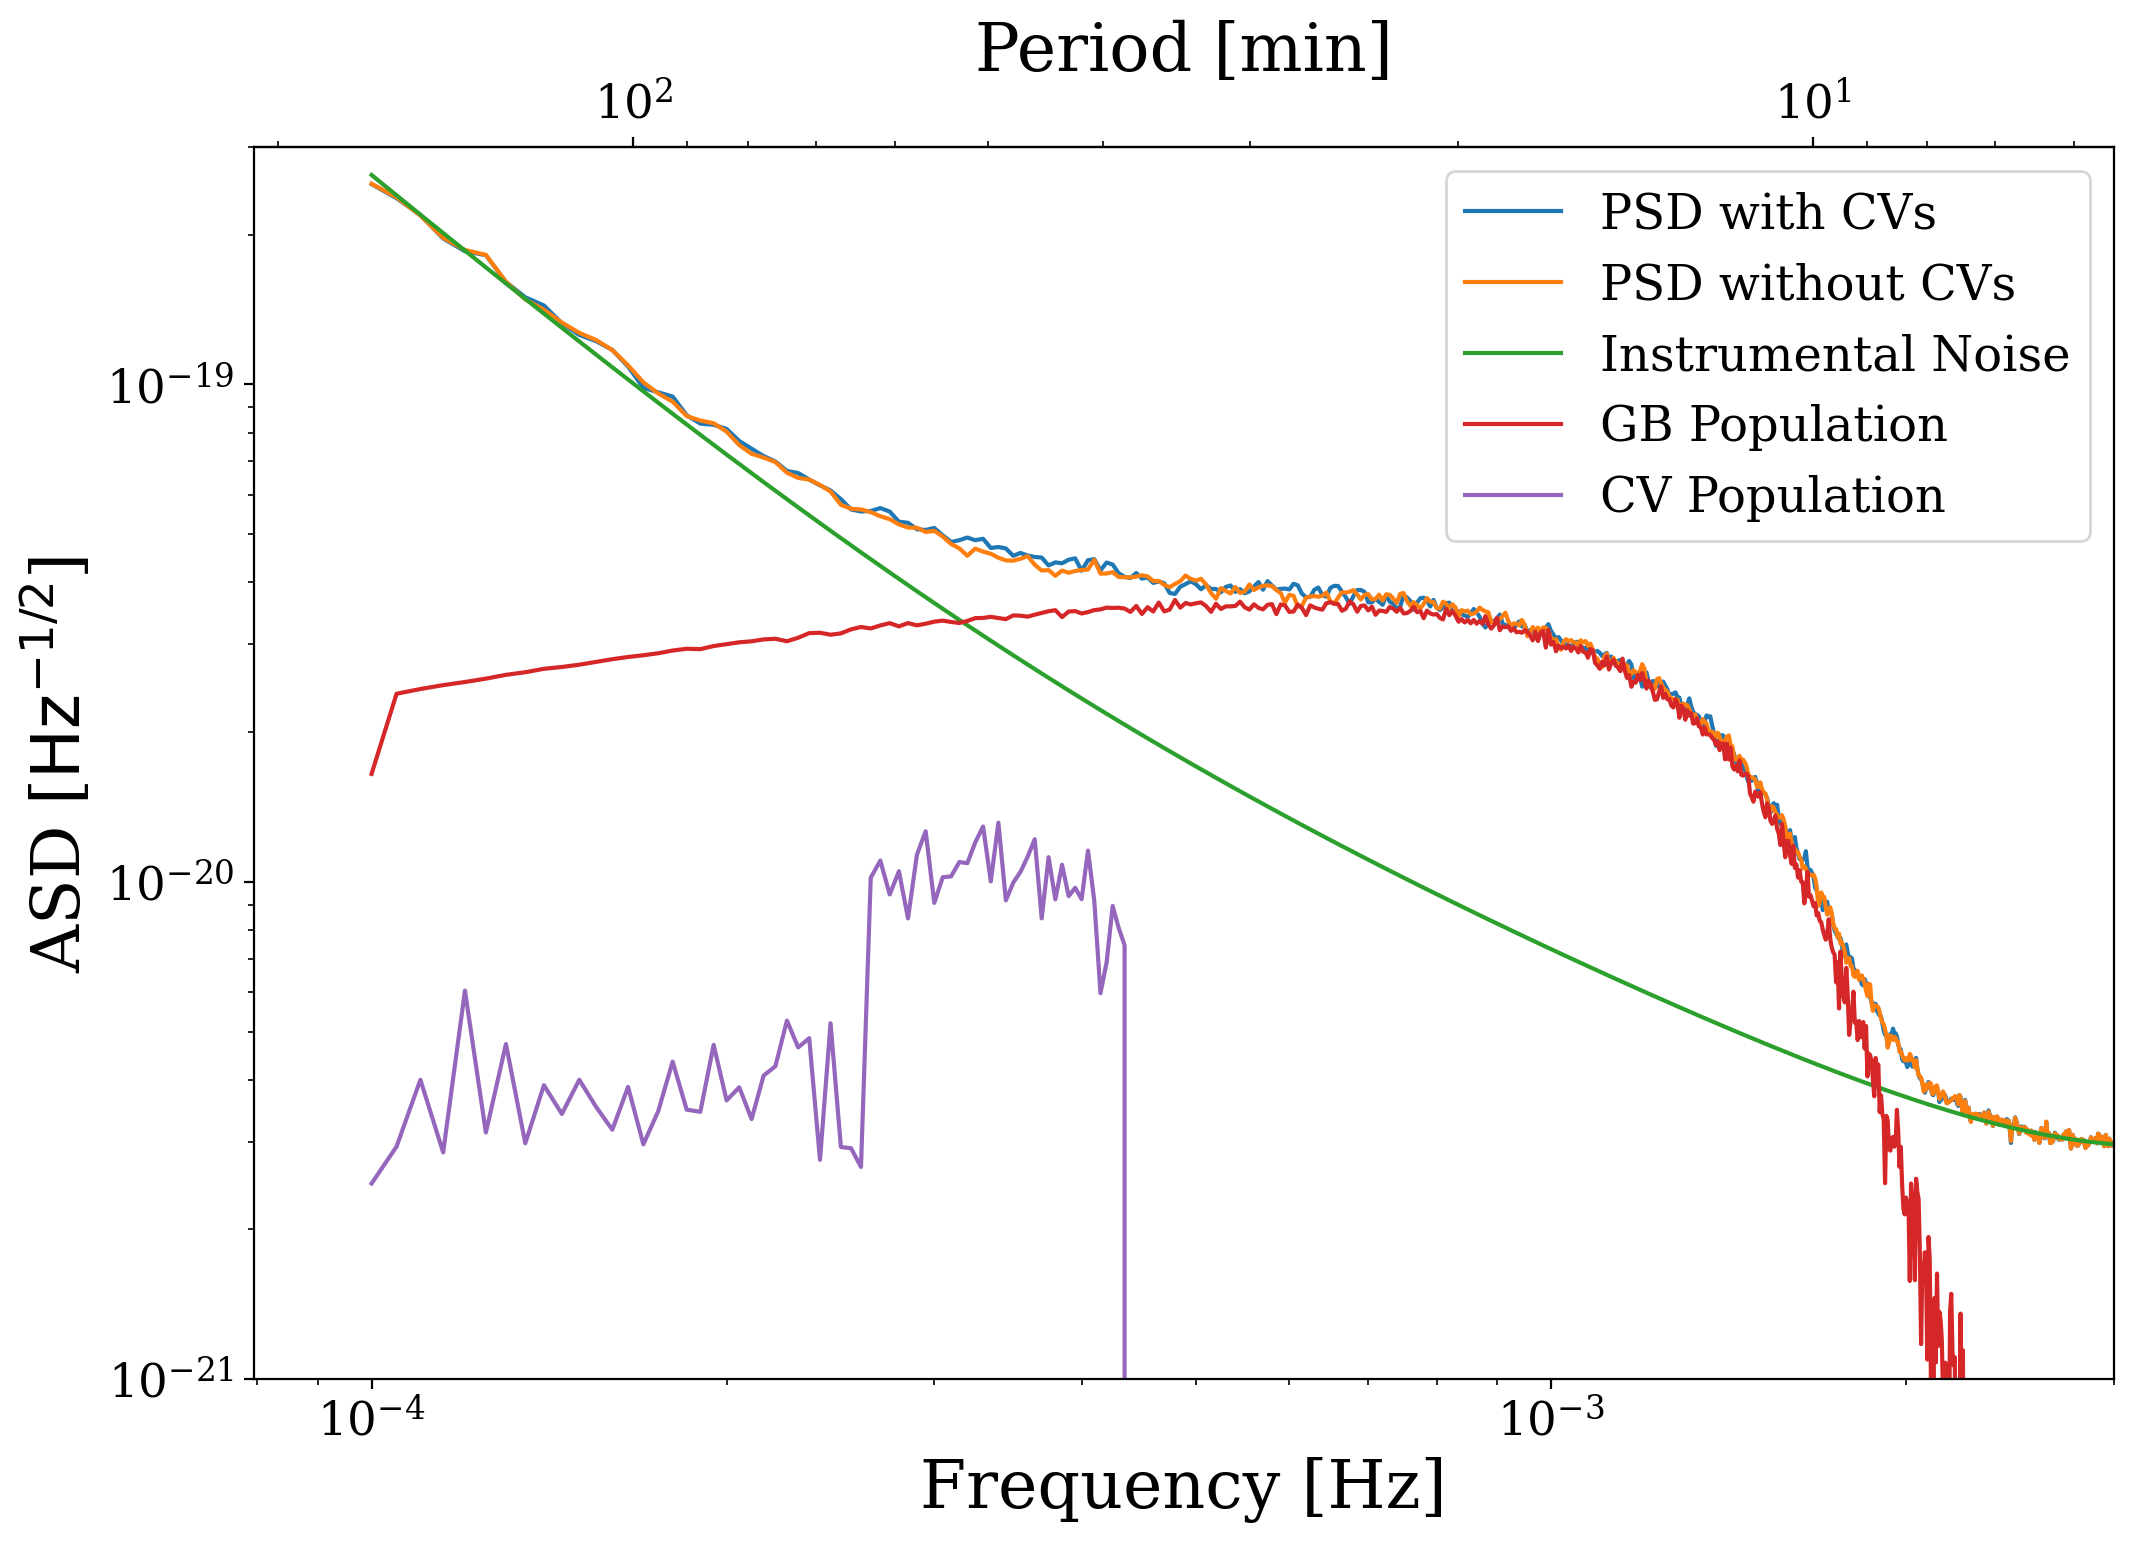

In [31]:
fig, ax = plt.subplots()


ax.plot(pops_CV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(pops_CV_plot['injspec_data']['data_psd']['psd1']), label='PSD with CVs')
ax.plot(pops_noCV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(pops_noCV_plot['injspec_data']['data_psd']['psd1']), label='PSD without CVs')
ax.plot(pops_CV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(pops_CV_plot['injspec_data']['noise_spectra']['noise1']), label='Instrumental Noise')
ax.plot(pops_CV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(pops_CV_plot['injspec_data']['population-2']['S1_gw']), label='GB Population')
ax.plot(pops_CV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(pops_CV_plot['injspec_data']['population-1']['S1_gw']), label='CV Population')

ax.loglog()
ax.set_xlim(right=3e-3)
ax.set_ylim(bottom=1e-21, top=3e-19)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel(r'ASD [$\rm{Hz}^{-1/2}$]')


secax = ax.secondary_xaxis('top', functions=(hztominperiod, minperiodtohz))
secax.set_xlabel('Period [min]')


plt.legend(fontsize='xx-large')

fig.savefig(f'/data/taylor_group/levi_schult/blip_CVs/notebooks/figures/aps2026/asd_comparison_i_CVpop_GBpop.png', 
            dpi=400, bbox_inches='tight', format='png')